# Pose Estimation Analysis Notebook

This notebook analyzes pose estimation results:
- Keypoint accuracy (PCK)
- Skeleton visualization
- Temporal consistency
- Occlusion handling

In [2]:
import sys
sys.path.insert(0, '..')

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
import json

## 1. Load Pose Schema

In [3]:
import yaml

schema_path = Path('../config/schemas/poultry.yaml')
schema = None

if schema_path.exists():
    with open(schema_path, 'r') as f:
        schema = yaml.safe_load(f)
    
    print("Poultry Pose Schema:")
    print(f"  Name: {schema.get('name')}")
    print(f"  Version: {schema.get('version')}")
    
    print("\nKeypoints:")
    for i, kp in enumerate(schema.get('keypoints', [])):
        print(f"  {i}: {kp['name']} ({kp['color']})")
    
    print(f"\nSkeleton connections: {len(schema.get('skeleton', []))}")
    print(f"Flip pairs: {schema.get('flip_pairs', [])}")
else:
    print("Schema not found")

Poultry Pose Schema:
  Name: Poultry Pose
  Version: 1.0

Keypoints:
  0: body_center (#FF6B6B)
  1: body_tail (#4ECDC4)
  2: body_knee_left (#45B7D1)
  3: body_knee_right (#96CEB4)
  4: body_heel_left (#FFEAA7)
  5: body_heel_right (#DDA0DD)
  6: eye_left (#98D8C8)
  7: eye_right (#F7DC6F)
  8: comb (#BB8FCE)
  9: beak (#F8B500)

Skeleton connections: 11
Flip pairs: [['body_knee_left', 'body_knee_right'], ['body_heel_left', 'body_heel_right'], ['eye_left', 'eye_right']]


## 2. Visualize Skeleton Structure

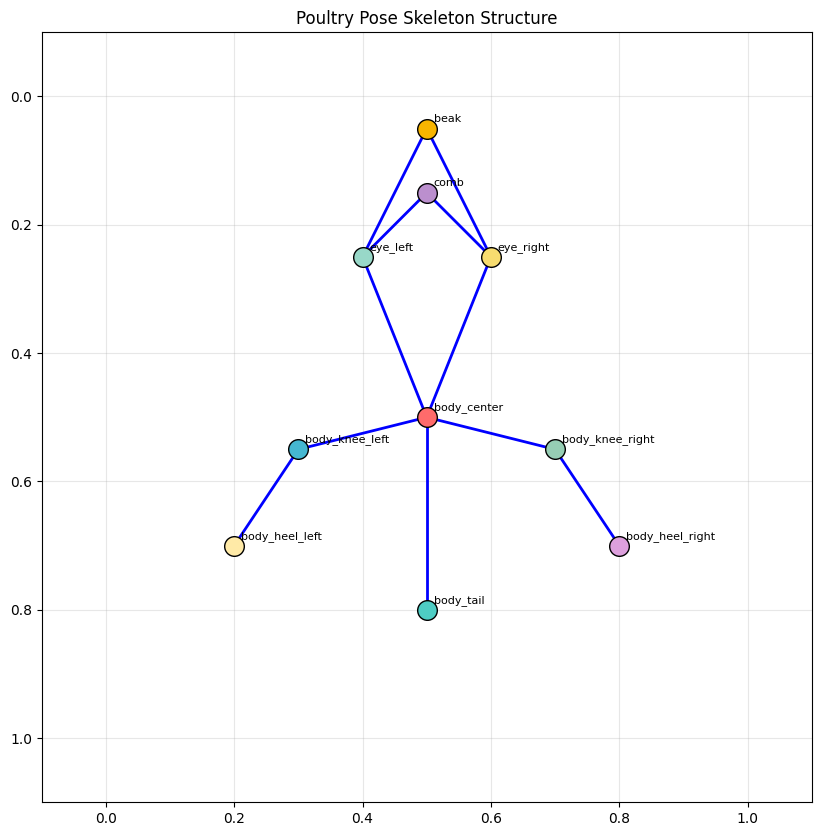

In [4]:
if schema:
    # Create visualization of skeleton structure
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Define approximate keypoint positions for visualization
    # Based on typical hen pose (top-down view)
    kp_positions = {
        'body_center': (0.5, 0.5),
        'body_tail': (0.5, 0.8),
        'body_knee_left': (0.3, 0.55),
        'body_knee_right': (0.7, 0.55),
        'body_heel_left': (0.2, 0.7),
        'body_heel_right': (0.8, 0.7),
        'eye_left': (0.4, 0.25),
        'eye_right': (0.6, 0.25),
        'comb': (0.5, 0.15),
        'beak': (0.5, 0.05)
    }
    
    keypoints = schema.get('keypoints', [])
    kp_names = [kp['name'] for kp in keypoints]
    
    # Draw skeleton
    for conn in schema.get('skeleton', []):
        i1, i2 = conn

        # Support skeleton entries as either indices (int) or keypoint names (str)
        n1 = kp_names[i1] if isinstance(i1, int) else i1
        n2 = kp_names[i2] if isinstance(i2, int) else i2

        if n1 in kp_positions and n2 in kp_positions:
            p1 = kp_positions[n1]
            p2 = kp_positions[n2]
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'b-', linewidth=2)
    
    # Draw keypoints
    for kp in keypoints:
        name = kp['name']
        if name in kp_positions:
            pos = kp_positions[name]
            color = kp['color']
            ax.scatter(pos[0], pos[1], c=color, s=200, zorder=5, edgecolors='black')
            ax.annotate(name, pos, textcoords="offset points", xytext=(5, 5), fontsize=8)
    
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(1.1, -0.1)  # Flip Y for image coordinates
    ax.set_aspect('equal')
    ax.set_title('Poultry Pose Skeleton Structure')
    ax.grid(True, alpha=0.3)
    plt.show()

## 3. Run Pose Inference

Loaded pose model: ../models/yolo11-pose.pt
f00015_frame004020_crop03.png keypoints (x, y):
[]
f00015_frame000120_crop05.png keypoints (x, y):
[]
cam_low_20251218_150124_07m_to_14m_rotated_frame000740_crop01.png keypoints (x, y):
[[[     83.259       132.1]
  [     50.759      124.54]
  [          0           0]
  [          0           0]
  [     54.745       144.4]
  [     64.322      155.74]
  [          0           0]
  [          0           0]
  [     26.907      117.54]
  [          0           0]]

 [[     70.668      136.68]
  [     37.139      110.47]
  [          0           0]
  [          0           0]
  [          0           0]
  [     55.578      161.19]
  [          0           0]
  [          0           0]
  [     19.265      110.71]
  [          0           0]]

 [[     130.58      111.28]
  [     106.59      62.062]
  [          0           0]
  [          0           0]
  [          0           0]
  [          0           0]
  [          0           0]
  [       

IndexError: index 3 is out of bounds for axis 0 with size 3

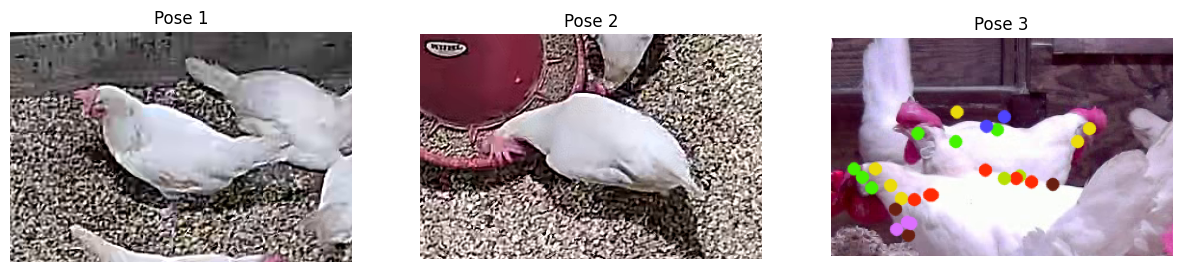

In [5]:
from ultralytics import YOLO

pose_model_path = Path('../models/yolo11-pose.pt')

if pose_model_path.exists():
    pose_model = YOLO(str(pose_model_path))
    print(f"Loaded pose model: {pose_model_path}")
    
    # Find sample images
    sample_images = list(Path('../poultry-data/images').glob('*.png'))[:5]
    
    if sample_images:
        fig, axes = plt.subplots(1, min(3, len(sample_images)), figsize=(15, 5))
        if len(sample_images) == 1:
            axes = [axes]
        
        last_results = None

        for i, img_path in enumerate(sample_images[:10]):
            results = pose_model(str(img_path), verbose=False)
            last_results = results

            # Remove boxes so only keypoints/skeleton are rendered by plot()
            if results and hasattr(results[0], "boxes"):
                results[0].boxes = None

            # Output keypoint coordinates
            if results and results[0].keypoints is not None and results[0].keypoints.xy is not None:
                print(f"{img_path.name} keypoints (x, y):")
                print(results[0].keypoints.xy.cpu().numpy())
            annotated = results[0].plot()

            # Handle multiple possible output formats from Ultralytics plot()
            if isinstance(annotated, np.ndarray):
                if annotated.ndim == 3 and annotated.shape[2] == 3:
                    # Convert BGR -> RGB without cv2 to avoid dtype/shape conversion errors
                    display_img = annotated[..., ::-1]
                elif annotated.ndim == 3 and annotated.shape[2] == 4:
                    # Convert BGRA -> RGBA
                    display_img = annotated[..., [2, 1, 0, 3]]
                else:
                    display_img = annotated
            else:
                display_img = np.asarray(annotated)

            axes[i].imshow(display_img)
            axes[i].set_title(f"Pose {i+1}")
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Print keypoint info
        if last_results is not None and last_results[0].keypoints is not None:
            print(f"\nKeypoints detected: {last_results[0].keypoints.shape}")
    else:
        print("No sample images found")
else:
    print(f"Pose model not found: {pose_model_path}")

## 4. Keypoint Distribution Analysis

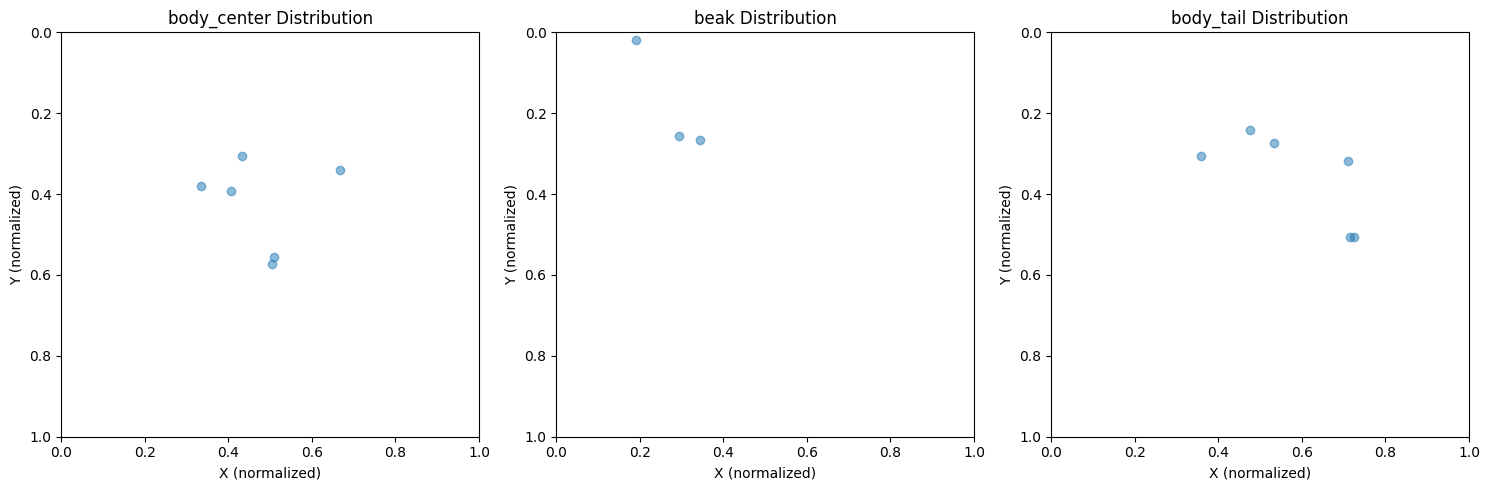

In [7]:
# Load annotations to analyze keypoint distribution
project_files = list(Path('..').rglob('*.poselabel'))

if project_files:
    with open(project_files[0], 'r') as f:
        project_data = json.load(f)
    
    frames = project_data.get('frames', {})
    schema_data = project_data.get('schema', {})
    kp_names = [kp['name'] for kp in schema_data.get('keypoints', [])]
    
    # Collect all keypoint positions
    all_positions = {name: {'x': [], 'y': []} for name in kp_names}
    
    for frame in frames.values():
        for instance in frame.get('instances', []):
            for kp_name, kp_data in instance.get('keypoints', {}).items():
                if kp_data.get('visibility', 0) > 0 and kp_name in all_positions:
                    all_positions[kp_name]['x'].append(kp_data['x'])
                    all_positions[kp_name]['y'].append(kp_data['y'])
    
    # Plot distribution for key body parts
    parts_to_plot = ['body_center', 'beak', 'body_tail']
    
    fig, axes = plt.subplots(1, len(parts_to_plot), figsize=(15, 5))
    
    for i, part in enumerate(parts_to_plot):
        if all_positions[part]['x']:
            axes[i].scatter(all_positions[part]['x'], all_positions[part]['y'], alpha=0.5)
            axes[i].set_xlabel('X (normalized)')
            axes[i].set_ylabel('Y (normalized)')
            axes[i].set_title(f'{part} Distribution')
            axes[i].set_xlim(0, 1)
            axes[i].set_ylim(1, 0)  # Flip Y
    
    plt.tight_layout()
    plt.show()
else:
    print("No annotation files found")

## 5. Summary

In [8]:
print("\n" + "="*50)
print("Pose Estimation Analysis Summary")
print("="*50)

if schema:
    print(f"Schema: {schema.get('name')}")
    print(f"Keypoints: {len(schema.get('keypoints', []))}")
    print(f"Skeleton connections: {len(schema.get('skeleton', []))}")

if 'project_data' in dir():
    total_kps = sum(len(pos['x']) for pos in all_positions.values())
    print(f"\nAnnotated keypoints: {total_kps}")
    print(f"Instances with keypoints: {sum(1 for f in frames.values() for i in f.get('instances', []) if i.get('keypoints'))}")


Pose Estimation Analysis Summary
Schema: Poultry Pose
Keypoints: 10
Skeleton connections: 11

Annotated keypoints: 44
Instances with keypoints: 7
